In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pathlib import Path
import wisardpkg as wp


In [ ]:
DATASET_DIR = "dataset_omr"

IMG_SIZE = (48, 48)

THRESHOLD = 127

In [3]:
def mostrar(img, titulo="", cmap="gray"):

    plt.figure(figsize=(4,4))

    plt.imshow(img, cmap=cmap)

    plt.title(titulo)

    plt.axis("off")

    plt.show()

In [4]:
def processar_imagem(caminho_img):

    # =====================================================
    # 1. ORIGINAL
    # =====================================================

    original = cv2.imread(caminho_img)

    original_rgb = cv2.cvtColor(
        original,
        cv2.COLOR_BGR2RGB
    )

    mostrar(original_rgb, "Imagem Original", cmap=None)

    # =====================================================
    # 2. ESCALA DE CINZA
    # =====================================================

    gray = cv2.cvtColor(
        original,
        cv2.COLOR_BGR2GRAY
    )

    mostrar(gray, "Escala de Cinza")

    # =====================================================
    # 3. RESIZE
    # =====================================================

    resized = cv2.resize(
        gray,
        IMG_SIZE
    )

    mostrar(resized, "Resize 32x32")

    # =====================================================
    # 4. BINARIZAÇÃO
    # =====================================================

    _, binary = cv2.threshold(
        resized,
        THRESHOLD,
        255,
        cv2.THRESH_BINARY_INV
    )

    mostrar(binary, "Imagem Binária")

    # =====================================================
    # 5. FLATTEN
    # =====================================================

    vetor = binary.flatten()

    vetor_binario = (vetor > 0).astype(np.uint8)

    print("Tamanho do vetor:", len(vetor_binario))

    print("\nPrimeiros 100 valores:\n")

    print(vetor_binario[:100])

    # =====================================================
    # 6. RECONSTRUÇÃO
    # =====================================================

    reconstruida = vetor_binario.reshape(32, 32)

    mostrar(reconstruida, "Reconstruída do Vetor")

    return vetor_binario

In [5]:
# pega automaticamente a primeira imagem encontrada

for classe in os.listdir(DATASET_DIR):

    pasta = os.path.join(DATASET_DIR, classe)

    if not os.path.isdir(pasta):
        continue

    arquivos = os.listdir(pasta)

    if len(arquivos) > 0:

        caminho_exemplo = os.path.join(
            pasta,
            arquivos[0]
        )

        classe_exemplo = classe

        break

print("Classe:", classe_exemplo)

print("Arquivo:", caminho_exemplo)

Classe: note-A2_double_whole.
Arquivo: dataset_omr/note-A2_double_whole./211002611-1_1_1_0007.png


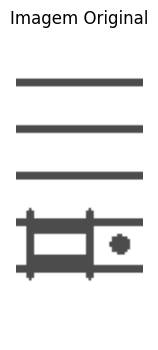

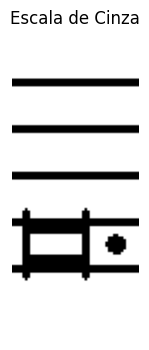

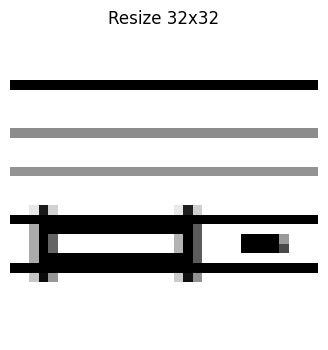

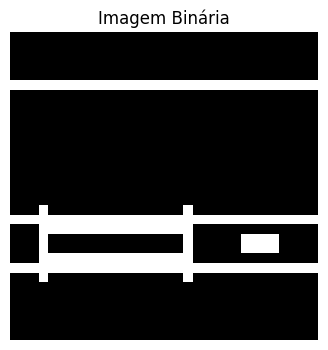

Tamanho do vetor: 1024

Primeiros 100 valores:

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


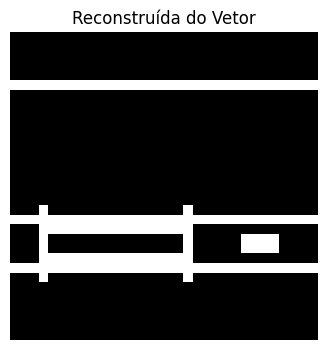

In [6]:
vetor_exemplo = processar_imagem(caminho_exemplo)

In [ ]:
def carregar_dataset(dataset_dir):

    X = []
    y = []

    classes = sorted(os.listdir(dataset_dir))

    for classe in classes:

        caminho_classe = os.path.join(
            dataset_dir,
            classe
        )

        if not os.path.isdir(caminho_classe):
            continue

        print(f"Lendo: {classe}")

        classe_base = classe.split("-")[0]

        for arquivo in os.listdir(caminho_classe):

            if not arquivo.lower().endswith(".png"):
                continue

            caminho_img = os.path.join(
                caminho_classe,
                arquivo
            )

            img = cv2.imread(
                caminho_img,
                cv2.IMREAD_GRAYSCALE
            )

            if img is None:
                continue

            img = cv2.resize(
                img,
                IMG_SIZE
            )

            _, img_bin = cv2.threshold(
                img,
                THRESHOLD,
                255,
                cv2.THRESH_BINARY_INV
            )

            vetor = img_bin.flatten()

            vetor = (vetor > 0).astype(np.uint8)

            X.append(vetor)

            y.append(classe_base)

    return np.array(X), np.array(y)

In [8]:
X, y = carregar_dataset(DATASET_DIR)

print("\nFormato X:", X.shape)

print("Formato y:", y.shape)

Lendo: barline
Lendo: clef-C1
Lendo: clef-C2
Lendo: clef-C3
Lendo: clef-C4
Lendo: clef-C5
Lendo: clef-F3
Lendo: clef-F4
Lendo: clef-G1
Lendo: clef-G2
Lendo: gracenote-A#4_eighth
Lendo: gracenote-A#4_half
Lendo: gracenote-A#4_quarter
Lendo: gracenote-A#4_sixteenth
Lendo: gracenote-A#4_thirty_second
Lendo: gracenote-A3_eighth
Lendo: gracenote-A3_quarter
Lendo: gracenote-A3_sixteenth
Lendo: gracenote-A3_thirty_second
Lendo: gracenote-A4_eighth
Lendo: gracenote-A4_half
Lendo: gracenote-A4_quarter
Lendo: gracenote-A4_sixteenth
Lendo: gracenote-A4_thirty_second
Lendo: gracenote-A5_eighth
Lendo: gracenote-A5_quarter
Lendo: gracenote-A5_sixteenth
Lendo: gracenote-A5_thirty_second
Lendo: gracenote-Ab3_thirty_second
Lendo: gracenote-Ab4_eighth
Lendo: gracenote-Ab4_quarter
Lendo: gracenote-Ab4_sixteenth
Lendo: gracenote-Ab4_thirty_second
Lendo: gracenote-Ab5_eighth
Lendo: gracenote-Ab5_sixteenth
Lendo: gracenote-Ab5_thirty_second
Lendo: gracenote-B#4_quarter
Lendo: gracenote-B#4_sixteenth
Lendo: 

In [9]:
from collections import Counter
from sklearn.model_selection import train_test_split

# =========================================================
# REMOVE CLASSES COM MENOS DE 2 EXEMPLOS
# =========================================================

contagem = Counter(y)

classes_validas = {
    classe
    for classe, qtd in contagem.items()
    if qtd >= 2
}

X_filtrado = []
y_filtrado = []

for xi, yi in zip(X, y):

    if yi in classes_validas:

        X_filtrado.append(xi)
        y_filtrado.append(yi)

X_filtrado = np.array(X_filtrado)
y_filtrado = np.array(y_filtrado)

print("Dataset original:", len(y))
print("Dataset filtrado:", len(y_filtrado))

Dataset original: 460735
Dataset filtrado: 460535


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_filtrado,
    y_filtrado,
    test_size=0.2,
    random_state=42,
    stratify=y_filtrado
)

print("Treino:", X_train.shape)

print("Teste :", X_test.shape)

Treino: (368428, 1024)
Teste : (92107, 1024)


In [11]:
addressSize = 16

wsd = wp.Wisard(addressSize)

print("WiSARD criada!")

WiSARD criada!


In [12]:
wsd.train(
    X_train.tolist(),
    y_train.tolist()
)

print("Treinamento finalizado!")

Treinamento finalizado!


In [13]:
saida = wsd.classify(
    X_test.tolist()
)

acertos = np.sum(
    np.array(saida) == y_test
)

acc = acertos / len(y_test)

print(f"\nAcurácia: {acc:.4f}")


Acurácia: 0.7597


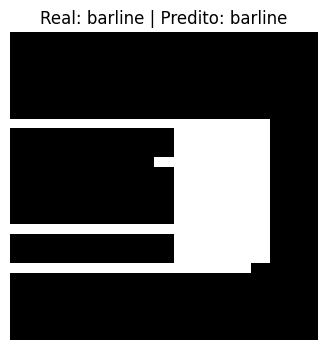

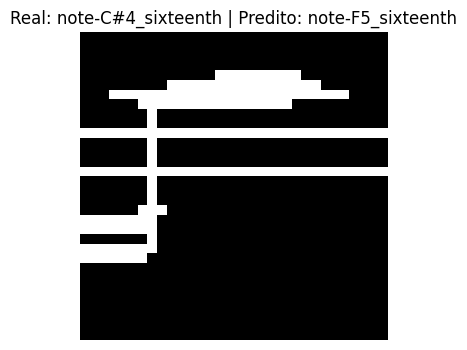

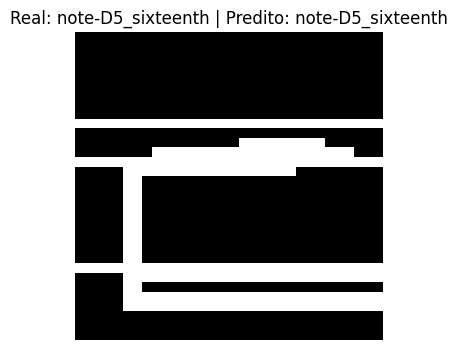

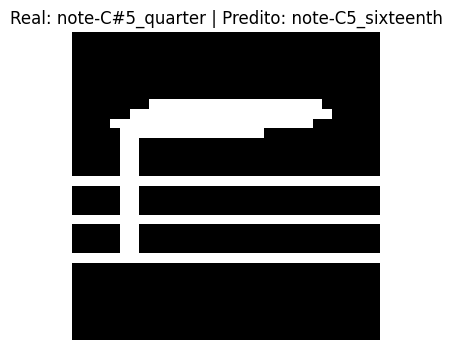

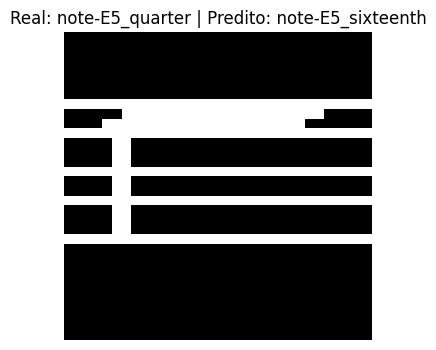

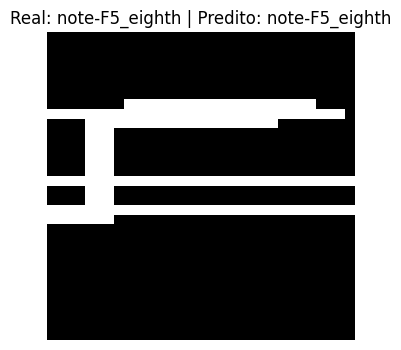

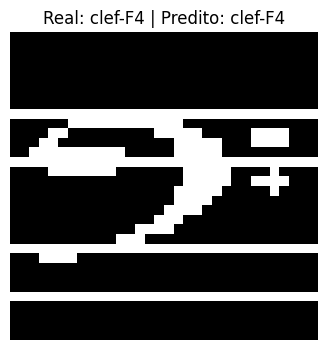

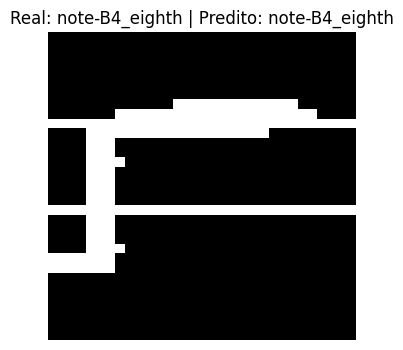

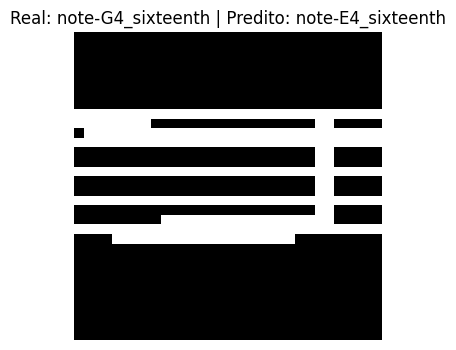

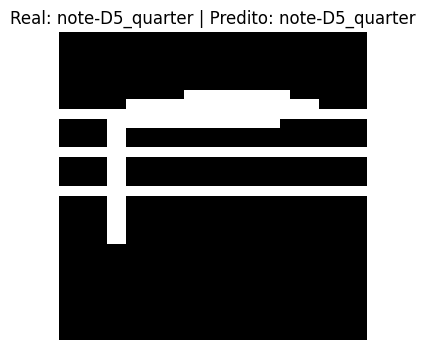

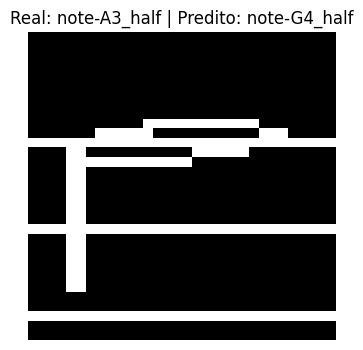

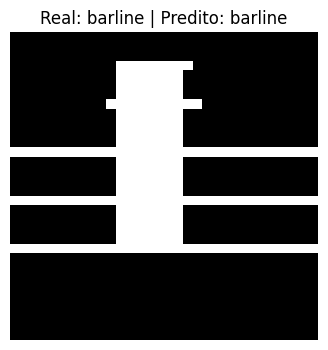

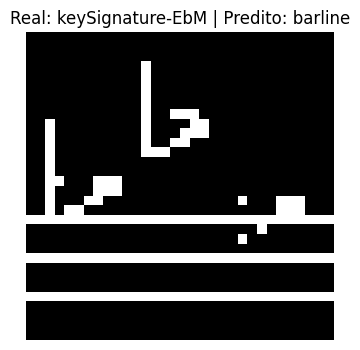

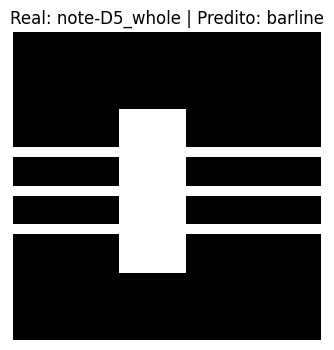

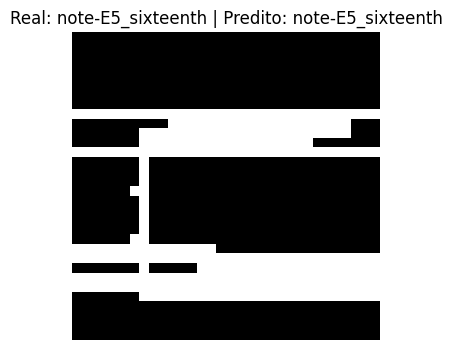

In [14]:
for i in range(15):

    img = X_test[i].reshape(32, 32)

    mostrar(img, f"Real: {y_test[i]} | Predito: {saida[i]}")

In [15]:
def classificar_partitura(pasta_partitura, wsd):

    imagens = []

    arquivos_png = sorted(
        Path(pasta_partitura).glob("*.png"),
        key=lambda x: int(x.stem.split("_")[-1])
    )

    for arquivo in arquivos_png:

        img = cv2.imread(
            str(arquivo),
            cv2.IMREAD_GRAYSCALE
        )

        img = cv2.resize(
            img,
            IMG_SIZE
        )

        _, img_bin = cv2.threshold(
            img,
            THRESHOLD,
            255,
            cv2.THRESH_BINARY_INV
        )

        vetor = img_bin.flatten()
        vetor = (vetor > 0).astype(np.uint8)

        imagens.append(vetor)

    predicoes = wsd.classify(imagens)

    return predicoes

In [16]:
def ler_semantic(pasta_partitura):

    semantic_file = next(
        Path(pasta_partitura).glob("*.semantic")
    )

    with open(
        semantic_file,
        "r",
        encoding="utf-8"
    ) as f:

        texto = f.read().strip()

    return texto.split()

In [17]:
def levenshtein_tokens(ref, hyp):

    m = len(ref)
    n = len(hyp)

    dp = [[0]*(n+1) for _ in range(m+1)]

    for i in range(m+1):
        dp[i][0] = i

    for j in range(n+1):
        dp[0][j] = j

    for i in range(1, m+1):
        for j in range(1, n+1):

            custo = 0 if ref[i-1] == hyp[j-1] else 1

            dp[i][j] = min(
                dp[i-1][j] + 1,
                dp[i][j-1] + 1,
                dp[i-1][j-1] + custo
            )

    return dp[m][n]

In [18]:
#PASTA_CORTES = "CORTES"

#total_dist = 0
#total_simbolos = 0

#seq_errors = 0
#total_partituras = 0

#for pasta in Path(PASTA_CORTES).iterdir():

#    if not pasta.is_dir():
#        continue

#    gt = ler_semantic(pasta)

#    pred = classificar_partitura(
#        pasta,
#        wsd
#    )

#    dist = levenshtein_tokens(
#        gt,
#        pred
#    )

#    total_dist += dist
#    total_simbolos += len(gt)

#    if gt != pred:
#        seq_errors += 1

#    total_partituras += 1

#    print(
#        f"{pasta.name} | "
#        f"SER={100*dist/len(gt):.2f}%"
#    )

#SER = total_dist / total_simbolos
#SeqER = seq_errors / total_partituras

#print("\n===================")
#print(f"SER   : {SER*100:.2f}%")
#print(f"SeqER : {SeqER*100:.2f}%")
#print("===================")